In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm
from tqdm import tqdm

In [2]:
class PDESystem:
    def __init__(self, grid_size, domain_size, S, M, params):
        """
        Initialize the PDE system solver.
        
        Parameters:
        -----------
        grid_size : int
            Number of grid points in each spatial dimension
        domain_size : float
            Physical size of the domain (assumed square)
        S : int
            Number of species N_i
        M : int
            Number of resources R_alpha
        params : dict
            Dictionary containing all parameters:
            - D_N : array of diffusion coefficients for N (size S)
            - D_alpha : array of diffusion coefficients for R (size M)
            - l_i_alpha : matrix of leakage terms (S x M)
            - w_alpha : array of weights (size M)
            - c_i_alpha : matrix of consumption rates (S x M)
            - m_i : array of mortality rates (size S)
            - kappa_alpha : array of resource input rates (size M)
            - rho_alpha : array of resource decay rates (size M)
            - D_i_alpha_beta : tensor of cross-feeding terms (S x M x M)
        """
        self.grid_size = grid_size
        self.domain_size = domain_size
        self.dx = domain_size / (grid_size - 1)  # Spatial step size
        self.S = S  # Number of species
        self.M = M  # Number of resources
        
        # Parameters
        self.D_N = params['D_N']  # Diffusion coefficients for N
        self.D_alpha = params['D_alpha']  # Diffusion coefficients for R
        self.l_i_alpha = params['l_i_alpha']  # Leakage terms
        self.w_alpha = params['w_alpha']  # Weights
        self.c_i_alpha = params['c_i_alpha']  # Consumption rates
        self.m_i = params['m_i']  # Mortality rates
        self.kappa_alpha = params['kappa_alpha']  # Resource input rates
        self.rho_alpha = params['rho_alpha']  # Resource decay rates
        self.D_i_alpha_beta = params['D_i_alpha_beta']  # Cross-feeding terms
        
        # Create spatial grid
        self.x = np.linspace(0, domain_size, grid_size)
        self.y = np.linspace(0, domain_size, grid_size)
        self.X, self.Y = np.meshgrid(self.x, self.y)
        
        # Total number of variables
        self.total_vars = S * grid_size * grid_size + M * grid_size * grid_size
        
        # For progress tracking
        self.pbar = None
        self.last_t = 0

    def laplacian_2d(self, u):
        """
        Compute the 2D Laplacian using finite differences.
        """
        u_shape = u.shape
        u_padded = np.pad(u, 1, mode='edge')
        
        # 5-point stencil for Laplacian
        laplacian = (
            u_padded[:-2, 1:-1] + u_padded[2:, 1:-1] + 
            u_padded[1:-1, :-2] + u_padded[1:-1, 2:] - 
            4 * u_padded[1:-1, 1:-1]
        ) / (self.dx ** 2)
        
        return laplacian

    def vector_to_grid(self, u):
        """
        Convert a flattened vector to grid representation for all species and resources.
        """
        N = np.zeros((self.S, self.grid_size, self.grid_size))
        R = np.zeros((self.M, self.grid_size, self.grid_size))
        
        # Extract N values
        for i in range(self.S):
            start_idx = i * self.grid_size * self.grid_size
            end_idx = (i + 1) * self.grid_size * self.grid_size
            N[i] = u[start_idx:end_idx].reshape(self.grid_size, self.grid_size)
        
        # Extract R values
        for alpha in range(self.M):
            start_idx = self.S * self.grid_size * self.grid_size + alpha * self.grid_size * self.grid_size
            end_idx = self.S * self.grid_size * self.grid_size + (alpha + 1) * self.grid_size * self.grid_size
            R[alpha] = u[start_idx:end_idx].reshape(self.grid_size, self.grid_size)
        
        return N, R

    def grid_to_vector(self, N, R):
        """
        Convert grid representation to flattened vector for all species and resources.
        """
        u = np.zeros(self.total_vars)
        
        # Flatten N values
        for i in range(self.S):
            start_idx = i * self.grid_size * self.grid_size
            end_idx = (i + 1) * self.grid_size * self.grid_size
            u[start_idx:end_idx] = N[i].flatten()
        
        # Flatten R values
        for alpha in range(self.M):
            start_idx = self.S * self.grid_size * self.grid_size + alpha * self.grid_size * self.grid_size
            end_idx = self.S * self.grid_size * self.grid_size + (alpha + 1) * self.grid_size * self.grid_size
            u[start_idx:end_idx] = R[alpha].flatten()
        
        return u

    def pde_system(self, t, u):
        """
        Define the PDE system as required by solve_ivp.
        """
        # Update progress bar
        if self.pbar is not None:
            # Calculate progress based on time
            t_progress = t - self.last_t
            if t_progress > 0:  # Only update if time has advanced
                self.pbar.update(t_progress)
                self.last_t = t
        
        N, R = self.vector_to_grid(u)
        
        # Initialize derivatives
        dNdt = np.zeros_like(N)
        dRdt = np.zeros_like(R)
        
        # Compute derivatives for each species
        for i in range(self.S):
            # Diffusion term
            dNdt[i] = self.D_N[i] * self.laplacian_2d(N[i])
            
            # Growth term
            growth = np.zeros_like(N[i])
            for alpha in range(self.M):
                growth += (1 - self.l_i_alpha[i, alpha]) * self.w_alpha[alpha] * self.c_i_alpha[i, alpha] * R[alpha]
            
            # Complete N_i equation
            dNdt[i] += N[i] * (growth - self.m_i[i])
        
        # Compute derivatives for each resource
        for alpha in range(self.M):
            # Diffusion term
            dRdt[alpha] = self.D_alpha[alpha] * self.laplacian_2d(R[alpha])
            
            # Input and decay terms
            dRdt[alpha] += self.kappa_alpha[alpha] - self.rho_alpha[alpha] * R[alpha]
            
            # Consumption term
            consumption = np.zeros_like(R[alpha])
            for i in range(self.S):
                consumption += N[i] * self.c_i_alpha[i, alpha] * R[alpha]
            dRdt[alpha] -= consumption
            
            # Cross-feeding term
            crossfeeding = np.zeros_like(R[alpha])
            for i in range(self.S):
                for beta in range(self.M):
                    crossfeeding += N[i] * self.D_i_alpha_beta[i, alpha, beta] * self.l_i_alpha[i, beta] * \
                                   (self.w_alpha[beta] / self.w_alpha[alpha]) * self.c_i_alpha[i, beta] * R[beta]
            dRdt[alpha] -= crossfeeding
        
        # Convert back to vector form
        dudt = self.grid_to_vector(dNdt, dRdt)
        return dudt

    def set_initial_conditions(self, init_funcs_N, init_funcs_R):
        """
        Set initial conditions using provided functions.
        
        Parameters:
        -----------
        init_funcs_N : list of functions
            Functions that take (x, y) and return initial value for each species
        init_funcs_R : list of functions
            Functions that take (x, y) and return initial value for each resource
        """
        N_init = np.zeros((self.S, self.grid_size, self.grid_size))
        R_init = np.zeros((self.M, self.grid_size, self.grid_size))
        
        # Set initial conditions for each species
        for i in range(self.S):
            for ix in range(self.grid_size):
                for iy in range(self.grid_size):
                    x, y = self.x[ix], self.y[iy]
                    N_init[i, iy, ix] = init_funcs_N[i](x, y)
        
        # Set initial conditions for each resource
        for alpha in range(self.M):
            for ix in range(self.grid_size):
                for iy in range(self.grid_size):
                    x, y = self.x[ix], self.y[iy]
                    R_init[alpha, iy, ix] = init_funcs_R[alpha](x, y)
        
        # Convert to vector form
        u0 = self.grid_to_vector(N_init, R_init)
        return u0

    def solve(self, t_span, t_eval, init_funcs_N, init_funcs_R):
        """
        Solve the PDE system with a progress bar.
        
        Parameters:
        -----------
        t_span : tuple
            (t_start, t_end)
        t_eval : array
            Time points to evaluate solution at
        init_funcs_N : list of functions
            Functions that take (x, y) and return initial value for each species
        init_funcs_R : list of functions
            Functions that take (x, y) and return initial value for each resource
            
        Returns:
        --------
        sol : OdeSolution
            Solution object from solve_ivp
        """
        u0 = self.set_initial_conditions(init_funcs_N, init_funcs_R)
        
        # Initialize progress bar
        self.last_t = t_span[0]
        total_time = t_span[1] - t_span[0]
        
        # Create progress bar
        with tqdm(total=total_time, desc="Solving PDE", unit="time units") as self.pbar:
            # Solve the system
            sol = solve_ivp(
                self.pde_system,
                t_span,
                u0,
                method='BDF',
                t_eval=t_eval,
                rtol=1e-4,
                atol=1e-6
            )
        
        # Reset progress bar
        self.pbar = None
        
        return sol

    def visualize_solution(self, sol, species_idx=0, resource_idx=0, time_idx=None):
        """
        Visualize the solution for a specific species and resource at a given time.
        
        Parameters:
        -----------
        sol : OdeSolution
            Solution from solve_ivp
        species_idx : int
            Index of species to visualize
        resource_idx : int
            Index of resource to visualize
        time_idx : int or None
            Index of time point to visualize. If None, visualize all time points.
        """
        if time_idx is not None:
            # Visualize a specific time point
            u = sol.y[:, time_idx]
            N, R = self.vector_to_grid(u)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
            
            # Plot species
            im1 = ax1.pcolormesh(self.X, self.Y, N[species_idx], cmap='viridis', shading='auto')
            ax1.set_title(f'Species N_{species_idx} at t = {sol.t[time_idx]:.2f}')
            ax1.set_xlabel('x')
            ax1.set_ylabel('y')
            plt.colorbar(im1, ax=ax1)
            
            # Plot resource
            im2 = ax2.pcolormesh(self.X, self.Y, R[resource_idx], cmap='plasma', shading='auto')
            ax2.set_title(f'Resource R_{resource_idx} at t = {sol.t[time_idx]:.2f}')
            ax2.set_xlabel('x')
            ax2.set_ylabel('y')
            plt.colorbar(im2, ax=ax2)
            
            plt.tight_layout()
            plt.show()
        else:
            # Create animation of all time points
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
            
            # Initialize plots
            u_init = sol.y[:, 0]
            N_init, R_init = self.vector_to_grid(u_init)
            
            im1 = ax1.pcolormesh(self.X, self.Y, N_init[species_idx], cmap='viridis', 
                                shading='auto', vmin=N_init[species_idx].min(), vmax=N_init[species_idx].max())
            ax1.set_title(f'Species N_{species_idx}')
            ax1.set_xlabel('x')
            ax1.set_ylabel('y')
            plt.colorbar(im1, ax=ax1)
            
            im2 = ax2.pcolormesh(self.X, self.Y, R_init[resource_idx], cmap='plasma', 
                                shading='auto', vmin=R_init[resource_idx].min(), vmax=R_init[resource_idx].max())
            ax2.set_title(f'Resource R_{resource_idx}')
            ax2.set_xlabel('x')
            ax2.set_ylabel('y')
            plt.colorbar(im2, ax=ax2)
            
            time_text = fig.suptitle(f't = {sol.t[0]:.2f}')
            
            def update(frame):
                u = sol.y[:, frame]
                N, R = self.vector_to_grid(u)
                
                im1.set_array(N[species_idx].flatten())
                im2.set_array(R[resource_idx].flatten())
                time_text.set_text(f't = {sol.t[frame]:.2f}')
                
                return im1, im2, time_text
            
            ani = FuncAnimation(fig, update, frames=len(sol.t), interval=100, blit=True)
            plt.tight_layout()
            plt.show()
            
            return ani

In [3]:
def example_simulation():
    """
    Run an example simulation with 2 species and 2 resources.
    """
    # Number of species and resources
    S = 2  # Number of species
    M = 2  # Number of resources
    
    # Grid parameters
    grid_size = 50  # Number of grid points in each dimension
    domain_size = 10.0  # Domain size (assumed square)
    
    # Set up parameters (these are example values, adjust as needed)
    D_N = np.array([0.1, 0.2])  # Diffusion coefficients for species
    D_alpha = np.array([0.05, 0.1])  # Diffusion coefficients for resources
    
    l_i_alpha = np.array([
        [0.1, 0.2],  # Leakage terms for species 1
        [0.15, 0.25]  # Leakage terms for species 2
    ])
    
    w_alpha = np.array([1.0, 1.5])  # Resource weights
    
    c_i_alpha = np.array([
        [0.5, 0.3],  # Consumption rates for species 1
        [0.4, 0.6]   # Consumption rates for species 2
    ])
    
    m_i = np.array([0.1, 0.15])  # Mortality rates
    
    kappa_alpha = np.array([0.2, 0.25])  # Resource input rates
    
    rho_alpha = np.array([0.1, 0.12])  # Resource decay rates
    
    # Cross-feeding terms (tensor S x M x M)
    D_i_alpha_beta = np.zeros((S, M, M))
    D_i_alpha_beta[0, 0, 1] = 0.05  # Species 1 converts resource 2 to resource 1
    D_i_alpha_beta[1, 1, 0] = 0.08  # Species 2 converts resource 1 to resource 2
    
    # Compile parameters
    params = {
        'D_N': D_N,
        'D_alpha': D_alpha,
        'l_i_alpha': l_i_alpha,
        'w_alpha': w_alpha,
        'c_i_alpha': c_i_alpha,
        'm_i': m_i,
        'kappa_alpha': kappa_alpha,
        'rho_alpha': rho_alpha,
        'D_i_alpha_beta': D_i_alpha_beta
    }
    
    # Initialize the PDE system
    pde_system = PDESystem(grid_size, domain_size, S, M, params)
    
    # Define initial conditions
    # Species 1: Gaussian peak in the center
    def init_N_1(x, y):
        return 0.5 * np.exp(-((x - domain_size/2)**2 + (y - domain_size/2)**2) / 2.0)
    
    # Species 2: Two Gaussian peaks
    def init_N_2(x, y):
        return 0.3 * np.exp(-((x - domain_size/3)**2 + (y - domain_size/3)**2) / 1.5) + \
               0.3 * np.exp(-((x - 2*domain_size/3)**2 + (y - 2*domain_size/3)**2) / 1.5)
    
    # Resource 1: Uniform distribution
    def init_R_1(x, y):
        return 1.0
    
    # Resource 2: Gradient from left to right
    def init_R_2(x, y):
        return 0.5 + 0.5 * (x / domain_size)
    
    init_funcs_N = [init_N_1, init_N_2]
    init_funcs_R = [init_R_1, init_R_2]
    
    # Solve the system
    t_span = (0, 20.0)
    t_points = 50
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    
    print("Solving PDE system...")
    sol = pde_system.solve(t_span, t_eval, init_funcs_N, init_funcs_R)
    print("Solution complete!")
    
    # Visualize the results
    print("Creating visualization...")
    pde_system.visualize_solution(sol, species_idx=0, resource_idx=0)
    
    return pde_system, sol


In [12]:
def CoSMO_simulation():
    """
    Run an example simulation with 2 species and 2 resources.
    """
    # Number of species and resources
    S = 2  # Number of species
    M = 3  # Number of resources
    
    # Grid parameters
    grid_size = 50  # Number of grid points in each dimension
    domain_size = 10.0  # Domain size (assumed square)
    
    # Set up parameters (these are example values, adjust as needed)
    D_N = np.array([0.01, 0.01])  # Diffusion coefficients for species
    D_alpha = np.array([1000,10,10])  # Diffusion coefficients for resources
    
    l_i_alpha = np.array([
        [1,0,0],  # Leakage terms for species 1
        [1,0,0]  # Leakage terms for species 2
    ])
    
    w_alpha = np.ones(M)  # Resource weights
    
    c_i_alpha = np.zeros((S,M))
    c_i_alpha[0,0] = 2
    c_i_alpha[1,0] = 2
    c_i_alpha[0,1] = 2
    c_i_alpha[1,2] = 2
    
    m_i = np.array([0.5, 0.5])  # Mortality rates
    
    kappa_alpha = np.array([1, 0,0])  # Resource input rates
    
    rho_alpha = np.ones(M)*0.3  # Resource decay rates
    
    # Cross-feeding terms (tensor S x M x M)
    D_i_alpha_beta = np.zeros((S, M, M))
    D_i_alpha_beta[0,2,0] = 1  # Species 1 converts resource 2 to resource 1
    D_i_alpha_beta[1,1,0] = 1  # Species 2 converts resource 1 to resource 2
    
    # Compile parameters
    params = {
        'D_N': D_N,
        'D_alpha': D_alpha,
        'l_i_alpha': l_i_alpha,
        'w_alpha': w_alpha,
        'c_i_alpha': c_i_alpha,
        'm_i': m_i,
        'kappa_alpha': kappa_alpha,
        'rho_alpha': rho_alpha,
        'D_i_alpha_beta': D_i_alpha_beta
    }
    
    # Initialize the PDE system
    pde_system = PDESystem(grid_size, domain_size, S, M, params)
    
    # Define initial conditions
    # Species 1: 0.5
    def init_N_1(x, y):
        return 0.5 + 0.1*(np.sin(5*x) + np.sin(5*y))
    
    # Species 2: Two Gaussian peaks
    def init_N_2(x, y):
        return 0.5
    
    # Resource 1: Uniform distribution
    def init_R_1(x, y):
        return 1.0
    
    # Resource 2: Gradient from left to right
    def init_R_2(x, y):
        return 0
    
     # Resource 2: Gradient from left to right
    def init_R_3(x, y):
        return 0
    
    init_funcs_N = [init_N_1, init_N_2]
    init_funcs_R = [init_R_1, init_R_2, init_R_3]
    
    # Solve the system
    t_span = (0, 20.0)
    t_points = 5
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    
    print("Solving PDE system...")
    sol = pde_system.solve(t_span, t_eval, init_funcs_N, init_funcs_R)
    print("Solution complete!")
    
    # Visualize the results
    print("Creating visualization...")
    pde_system.visualize_solution(sol, species_idx=0, resource_idx=0)
    
    return pde_system, sol

Solving PDE:   0%|          | 0/20.0 [00:00<?, ?time units/s]

Solving PDE system...


Solving PDE: 100%|██████████| 20.0/20.0 [09:17<00:00, 27.86s/time units]                           


Solution complete!
Creating visualization...


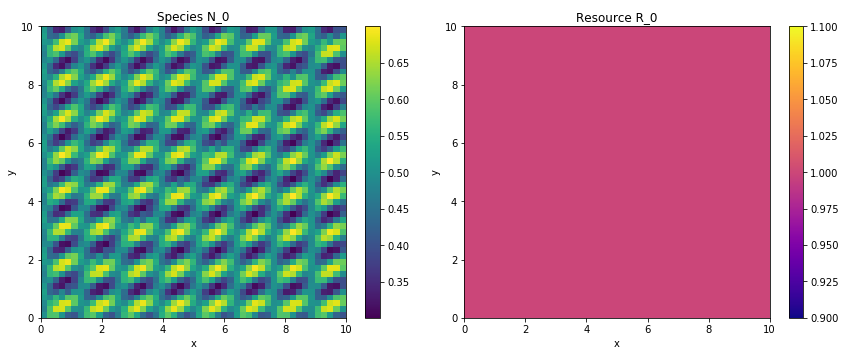

In [13]:
if __name__ == "__main__":
    CoSMO_simulation()